# DDSP Timbre Transfer (Local)

This notebook loads a local DDSP checkpoint and resynthesizes audio using extracted f0 and loudness features.

Requirements: `ddsp`, `librosa`, `soundfile`, `tensorflow`, and `gin`.

In [1]:
import glob
import os
import time
import sys
from pathlib import Path

import gin
import librosa
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import tensorflow.compat.v2 as tf

import ddsp
import ddsp.training

# Add src to path for local imports
PROJECT_ROOT = Path("../../").resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from model_loading import find_model_dir, find_latest_checkpoint
from feature_utils import (
    auto_adjust_features,
    compute_alignment,
    compute_features,
    load_dataset_stats,
    shift_f0,
    shift_loudness,
    trim_features,
)
from timbre_transfer import load_model, resynthesize
from visualize import plot_spectrograms, plot_features

DEFAULT_SAMPLE_RATE = 16000

2026-03-09 20:30:19.630811: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-09 20:30:19.949134: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 20:30:21.275452: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda-11.8/lib64:/usr/local/cuda-11.2/lib64:
2026-03-09 20:30:21.275795: W tensorflow/co

In [2]:
# Parameters
input_audio_dir = PROJECT_ROOT / "data/raw/voice/acapella"
output_audio_dir = PROJECT_ROOT / "data/processed/voice/acapella_transfered"
sample_rate = DEFAULT_SAMPLE_RATE

pitch_shift = 0.0        # octaves
loudness_shift = 0.0     # dB
auto_adjust = True       # match pitch register + loudness to training data
threshold = 1.0          # note detection sensitivity
quiet = 20.0             # suppress silent regions (dB)
autotune = 0.0           # snap to nearest scale note (0 = off, 1 = full)

In [3]:
# Load audio and extract segment 2:07 – 2:25
start_sec = 2 * 60 + 7   # 2:07
end_sec   = 2 * 60 + 25  # 2:25

wav_files = sorted(
    f for f in os.listdir(input_audio_dir) if f.endswith(".wav")
)
if not wav_files:
    raise ValueError(f"No .wav files found in {input_audio_dir}")

src_path = os.path.join(input_audio_dir, wav_files[0])
full_audio, _ = librosa.load(src_path, sr=sample_rate, mono=True)

start_sample = int(start_sec * sample_rate)
end_sample   = int(end_sec * sample_rate)
segment = full_audio[start_sample:end_sample]

print(f"Loaded: {src_path}")
print(f"  Full length: {len(full_audio)/sample_rate:.1f}s")
print(f"  Extracted segment: {start_sec}s – {end_sec}s ({len(segment)/sample_rate:.2f}s)")

from IPython.display import Audio, display
display(Audio(segment, rate=sample_rate))

Loaded: /home/namkhanh/Project/final_project/data/raw/voice/acapella/adele-rolling-in-the-deep-acapella.wav
  Full length: 222.4s
  Extracted segment: 127s – 145s (18.00s)


In [4]:
# Compute features on the extracted segment only
audio = segment[np.newaxis, :]
audio_features = compute_features(audio)

output_audio = os.path.join(
    output_audio_dir, wav_files[0].replace(".wav", "_TRANSFERED.wav")
)
audio_items = [
    {
        "input_path": src_path,
        "output_path": output_audio,
        "audio": audio,
        "features": audio_features,
    }
]
print(f"Computed features for segment ({segment.shape[0]/sample_rate:.2f}s)")

2026-03-09 20:30:27.679899: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-09 20:30:27.808694: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-09 20:30:27.808757: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-09 20:30:27.810477: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other ope

Computed features for segment (18.00s)


In [5]:
# Load model, compute alignment, apply conditioning, resynthesize
model_dir = find_model_dir(str(PROJECT_ROOT / "artifacts/trained_noreverb"))

gin_file = os.path.join(model_dir, 'operative_config-0.gin')
if not tf.io.gfile.exists(gin_file):
    gin_candidates = glob.glob(os.path.join(model_dir, '*.gin'))
    if not gin_candidates:
        raise FileNotFoundError('No gin file found in model_dir')
    gin_file = gin_candidates[0]

dataset_stats = load_dataset_stats(model_dir)
print(f"Dataset stats: {'loaded' if dataset_stats else 'not found (auto-adjust will be skipped)'}")

# Build model (internally parses gin, aligns dims, restores checkpoint)
init_audio = audio_items[0]["audio"]
init_features = audio_items[0]["features"]
model, _ = load_model(model_dir, gin_file, init_audio, init_features)

# Get alignment from the gin config (now active after load_model)
time_steps, n_samples, hop_size = compute_alignment(init_audio)
print(f"Alignment: {time_steps} frames × {hop_size} hop = {n_samples} samples")

demo_audio = None
demo_audio_gen = None

for idx, item in enumerate(audio_items):
    audio = item["audio"]
    audio_features = {k: v.copy() if hasattr(v, 'copy') else v
                      for k, v in item["features"].items()}

    # 1. Trim features to exact model dimensions
    audio_features = trim_features(audio_features, time_steps, n_samples)

    # 2. Auto-adjust: match pitch register + loudness to training data
    if auto_adjust and dataset_stats is not None:
        audio_features = auto_adjust_features(
            audio_features,
            dataset_stats,
            threshold=threshold,
            quiet=quiet,
            autotune_amount=autotune,
        )
        print(f"  [{idx}] Applied auto-adjust (threshold={threshold}, quiet={quiet}dB, autotune={autotune})")
    else:
        print(f"  [{idx}] Auto-adjust skipped")

    # 3. Manual shifts
    audio_features = shift_loudness(audio_features, loudness_shift)
    audio_features = shift_f0(audio_features, pitch_shift)

    # 4. Resynthesize
    audio_gen = resynthesize(model, audio_features)

    os.makedirs(os.path.dirname(item["output_path"]), exist_ok=True)
    sf.write(item["output_path"], audio_gen, sample_rate)
    print(f"  [{idx}] Wrote {item['output_path']}")

    if idx == 0:
        demo_audio = audio
        demo_audio_gen = audio_gen

# Keep the first sample for display
audio = demo_audio
audio_gen = demo_audio_gen

Dataset stats: not found (auto-adjust will be skipped)


/home/namkhanh/miniconda3/envs/conda_env3.10/lib/python3.10/site-packages/librosa/core/convert.py:1869: RuntimeWarning: divide by zero encountered in log10
  + 2 * np.log10(f_sq)


Restoring model took 0.8 seconds
Alignment: 4500 frames × 64 hop = 288000 samples
  [0] Auto-adjust skipped
Prediction took 0.2 seconds
  [0] Wrote /home/namkhanh/Project/final_project/data/processed/voice/acapella_transfered/adele-rolling-in-the-deep-acapella_TRANSFERED.wav


In [6]:
# Listen back (first sample only)
from IPython.display import Audio, display
display(Audio(audio[0], rate=sample_rate))
display(Audio(audio_gen, rate=sample_rate))

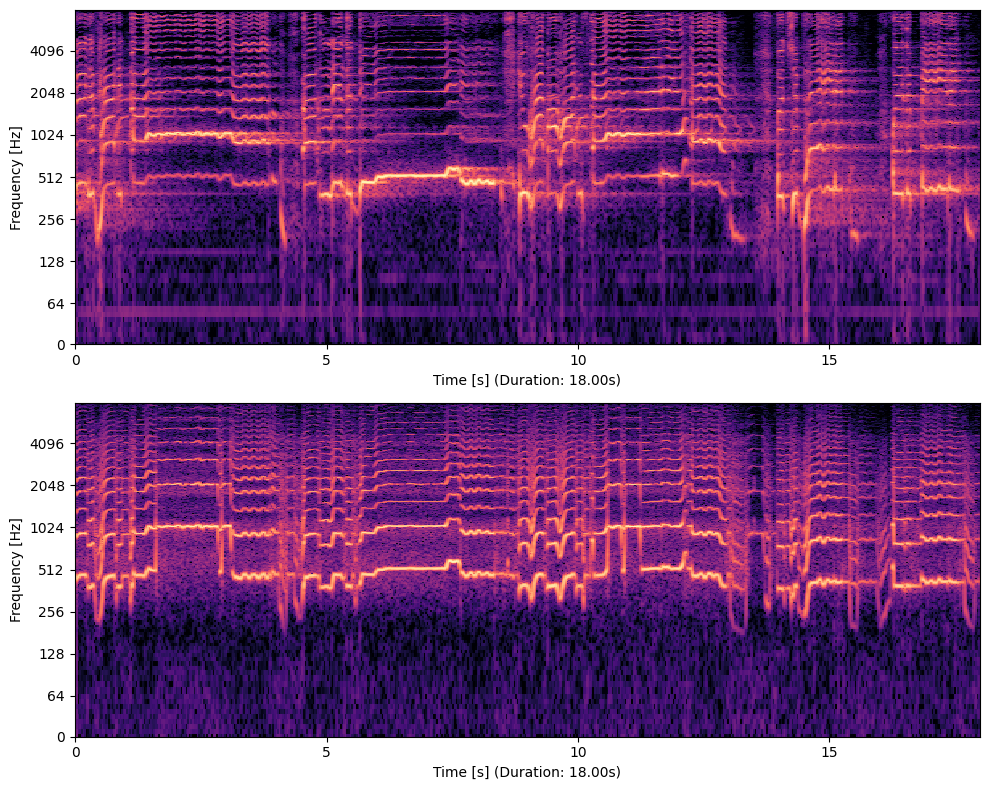

In [7]:
# Spectrograms (first sample only)
plot_spectrograms([audio[0], audio_gen], sample_rate)